# Train high-bound U-Tikhonov

This is the second bounded U-Tikhonov experiment. It keeps the SeaTurtle selection, split, architecture, optimizer,
epochs, and training-noise distribution unchanged, while changing:

- the upper bound from $4\lambda^*$ to $16\lambda^*$;
- fixed unrolled CG depth from 32 to 64 iterations.

The final section compares the 64-step reconstruction with a tightly converged
CG solution on validation images.

## Project root discovery & Imports

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def locate_project_root() -> Path:
    """Find cleaned_pipeline regardless of where Jupyter was launched."""
    cwd = Path.cwd().resolve()
    candidates = []
    for base in (cwd, *cwd.parents):
        candidates.extend((base, base / "cleaned_pipeline"))
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "scripts").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find cleaned_pipeline. Start Jupyter from Thesis/Python, "
        "cleaned_pipeline, or cleaned_pipeline/notebooks."
    )


PROJECT_ROOT = locate_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline


In [2]:
from argparse import Namespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from scripts.train_u_tikhonov import (
    load_reference_lambda,
    train_u_tikhonov,
)
from src.models.cg_tikhonov import weighted_tikhonov_operator
from src.solvers.conjugate_gradient import cg_solve_until_converged
from src.training.denoising import build_seaturtle_loaders, get_device
from src.utils.metrics import batch_psnr, batch_ssim

device = get_device()
print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.12.0
Device: mps


## Scalar reference and data validation

The selected scalar $\lambda^*$ is read from Notebook 02. This cell validates the training data and scalar-baseline summary, then loads the calibrated reference lambda and recommended CG depth used to define the controlled experiment. Edit `SEA_TURTLE_ROOT` to your own SeaTurtle images path.

In [3]:
SEA_TURTLE_ROOT = Path(
    "/Users/kyrillguba/.cache/kagglehub/datasets/"
    "wildlifedatasets/seaturtleid2022/versions/4"
).expanduser()
SCALAR_SUMMARY_PATH = (
    PROJECT_ROOT
    / "results"
    / "tikhonov"
    / "scalar_tikhonov_baseline_summary.csv"
)

if not SEA_TURTLE_ROOT.is_dir():
    raise FileNotFoundError(
        f"SeaTurtle root not found: {SEA_TURTLE_ROOT}. "
        "Edit SEA_TURTLE_ROOT before continuing."
    )
if not SCALAR_SUMMARY_PATH.is_file():
    raise FileNotFoundError(
        f"Missing scalar baseline: {SCALAR_SUMMARY_PATH}. "
        "Run notebook 02 first."
    )

scalar_summary = pd.read_csv(SCALAR_SUMMARY_PATH)
reference_lambda = load_reference_lambda(SCALAR_SUMMARY_PATH)

print("Reference scalar lambda:", reference_lambda)
display(scalar_summary)

Reference scalar lambda: 2.080083823051904


,best_scalar_lambda,validation_mse,validation_psnr,validation_ssim,average_converged_cg_iters,minimum_converged_cg_iters,maximum_converged_cg_iters,recommended_fixed_cg_iters,validation_sigma,validation_noise_seed
0,2.080084,0.001103,29.932832,0.775427,26.44,25,28,32,0.1,10000


## High-bound experiment setup
This cell sets the x16 lambda upper bound and 64 CG iterations, derives the run directory and map scale, and protects any completed run from accidental overwrite. The initial map is still exactly $\lambda^*$, not the midpoint of the new
interval. The large bound therefore adds capacity without making the initial
reconstruction over-smoothed.

In [4]:
LAMBDA_MAX_MULTIPLIER = 16.0
CG_ITERS = 64
RUN_NAME = (
    f"u_tikhonov_bounded_x{int(LAMBDA_MAX_MULTIPLIER)}"
    f"_cg{CG_ITERS}"
)
OVERWRITE_EXISTING_RUN = False

lambda_min = 1e-4
lambda_max = LAMBDA_MAX_MULTIPLIER * reference_lambda
checkpoint_dir = PROJECT_ROOT / "checkpoints" / RUN_NAME

if (
    not OVERWRITE_EXISTING_RUN
    and (checkpoint_dir / "history.csv").is_file()
):
    raise FileExistsError(
        f"Run already exists: {checkpoint_dir}. "
        "Change RUN_NAME or set OVERWRITE_EXISTING_RUN=True deliberately."
    )

# For 2-D forward differences, ||D||^2 <= 8. This is a conservative
# upper bound for kappa(I + D^T Lambda D), not a measured condition number.
condition_number_upper_bound = 1.0 + 8.0 * lambda_max

print("Run:", RUN_NAME)
print("lambda_min:", lambda_min)
print("lambda_max:", lambda_max)
print("CG iterations:", CG_ITERS)
print(
    "Conservative condition-number upper bound:",
    condition_number_upper_bound,
)

Run: u_tikhonov_bounded_x16_cg64
lambda_min: 0.0001
lambda_max: 33.281341168830465
CG iterations: 64
Conservative condition-number upper bound: 267.2507293506437


This cell collects the dataset, architecture, solver, optimisation, noise, seed, and output settings into the namespace consumed by the training pipeline.

In [5]:
args = Namespace(
    data_root=str(SEA_TURTLE_ROOT),
    checkpoint_dir=str(checkpoint_dir),

    image_size=256,
    max_images=550,
    val_images=50,

    # Kept identical to the earlier learned-model runs so this experiment
    # isolates the bound/solver changes.
    sigma_min=0.0,
    sigma_max=0.2,
    val_sigma=0.1,
    val_noise_seed=10_000,

    base_channels=32,
    depth=3,

    cg_iters=CG_ITERS,
    cg_relative_tol=1e-7,

    reference_lambda=float(reference_lambda),
    scalar_baseline_summary=str(SCALAR_SUMMARY_PATH),
    map_scale=None,

    lambda_parameterization="bounded_sigmoid",
    lambda_min=lambda_min,
    lambda_max=float(lambda_max),

    epochs=20,
    batch_size=1,
    lr=1e-4,
    weight_decay=1e-5,
    grad_clip=1.0,

    num_workers=0,
    print_every=50,
    seed=42,
    device=None,
    clamp_for_metrics=True,
)

train_loader, val_loader = build_seaturtle_loaders(args)

assert len(train_loader.dataset) == 500
assert len(val_loader.dataset) == 50
assert torch.equal(
    val_loader.dataset[0]["noisy"],
    val_loader.dataset[0]["noisy"],
)

print("Training images:", len(train_loader.dataset))
print("Validation images:", len(val_loader.dataset))
print("Validation sigma:", float(val_loader.dataset[0]["sigma"]))

Training images: 500
Validation images: 50
Validation sigma: 0.10000000149011612


## Train and create the new checkpoint

In [6]:
model_tikhonov_high, history_high = train_u_tikhonov(
    args,
    train_loader=train_loader,
    val_loader=val_loader,
)
display(history_high.tail())

Using device: mps
Model: u_tikhonov | train images: 500 | validation images: 50
Epoch 001 | batch 0050/0500 | train MSE 1.958152e-03
Epoch 001 | batch 0100/0500 | train MSE 6.435108e-04
Epoch 001 | batch 0150/0500 | train MSE 1.457181e-04
Epoch 001 | batch 0200/0500 | train MSE 1.717404e-03
Epoch 001 | batch 0250/0500 | train MSE 2.393768e-03
Epoch 001 | batch 0300/0500 | train MSE 1.391147e-03
Epoch 001 | batch 0350/0500 | train MSE 2.202136e-03
Epoch 001 | batch 0400/0500 | train MSE 1.104176e-03
Epoch 001 | batch 0450/0500 | train MSE 1.373213e-03
Epoch 001 | batch 0500/0500 | train MSE 3.291937e-03
Epoch 001 | train MSE 1.228827e-03 | val MSE 1.132920e-03 | val PSNR 29.972 | val SSIM 0.7950 | noisy PSNR 20.137 | saved best
Epoch 002 | batch 0050/0500 | train MSE 1.363547e-03
Epoch 002 | batch 0100/0500 | train MSE 8.019976e-04
Epoch 002 | batch 0150/0500 | train MSE 1.170171e-03
Epoch 002 | batch 0200/0500 | train MSE 1.336794e-03
Epoch 002 | batch 0250/0500 | train MSE 4.328944e-0

,epoch,train_mse,val_mse,val_psnr,val_ssim,noisy_mse,noisy_psnr,noisy_ssim,train_phase_time_sec,validation_time_sec,...,validation_images_per_sec,val_lambda_mean,val_lambda_std,val_lambda_min,val_lambda_max,val_lambda_p01,val_lambda_median,val_lambda_p99,val_lambda_lower_saturation_fraction,val_lambda_upper_saturation_fraction
15,16,0.000733,0.000787,31.576374,0.863603,0.009698,20.136563,0.322267,137.124126,8.214811,...,6.086568,11.070646,8.421605,0.034020,32.698952,0.661784,8.852191,29.000994,0.006239,0.000000
16,17,0.000750,0.000805,31.434152,0.858484,0.009698,20.136563,0.322267,137.483966,8.201028,...,6.096797,7.111721,5.810434,0.017715,32.241039,0.501612,5.318281,23.316240,0.011111,0.000000
17,18,0.000766,0.000776,31.637609,0.866054,0.009698,20.136563,0.322267,136.541613,8.188687,...,6.105985,11.987208,9.513213,0.022749,33.185024,0.617576,9.239819,31.194820,0.006719,0.003877
18,19,0.000734,0.000776,31.626655,0.866282,0.009698,20.136563,0.322267,137.471128,8.210169,...,6.090008,11.388060,9.358497,0.027226,33.151199,0.595244,8.460644,30.901783,0.006055,0.001895
19,20,0.000773,0.000784,31.564640,0.861116,0.009698,20.136563,0.322267,136.855533,8.163867,...,6.124549,7.844735,6.147797,0.024996,32.552410,0.618672,5.936988,24.585195,0.006495,0.000000


In [10]:
history_high['total_time_sec']

0       84.719369
1      170.272119
2      262.943458
3      361.509361
4      461.103546
5      559.939584
6      673.276684
7      797.492661
8      934.455066
9     1073.656956
10    1216.903331
11    1361.979534
12    1504.688651
13    1649.303195
14    1793.873328
15    1939.266837
16    2085.062127
17    2229.856011
18    2375.652875
19    2520.736206
Name: total_time_sec, dtype: float64

## Training quality, map range, and timing

These cells reload the experiment history and summary, plot optimisation, validation, lambda-map, and residual trajectories, save the diagnostic figure, and perform a bound-saturation check to identify any validation columns measuring proximity to the lambda bounds and display their final-epoch values.

`train_phase_time_sec` measures forward/backward/optimizer work;
`validation_time_sec` measures the fixed validation pass. Accelerator work is
synchronized before all wall-clock readings.

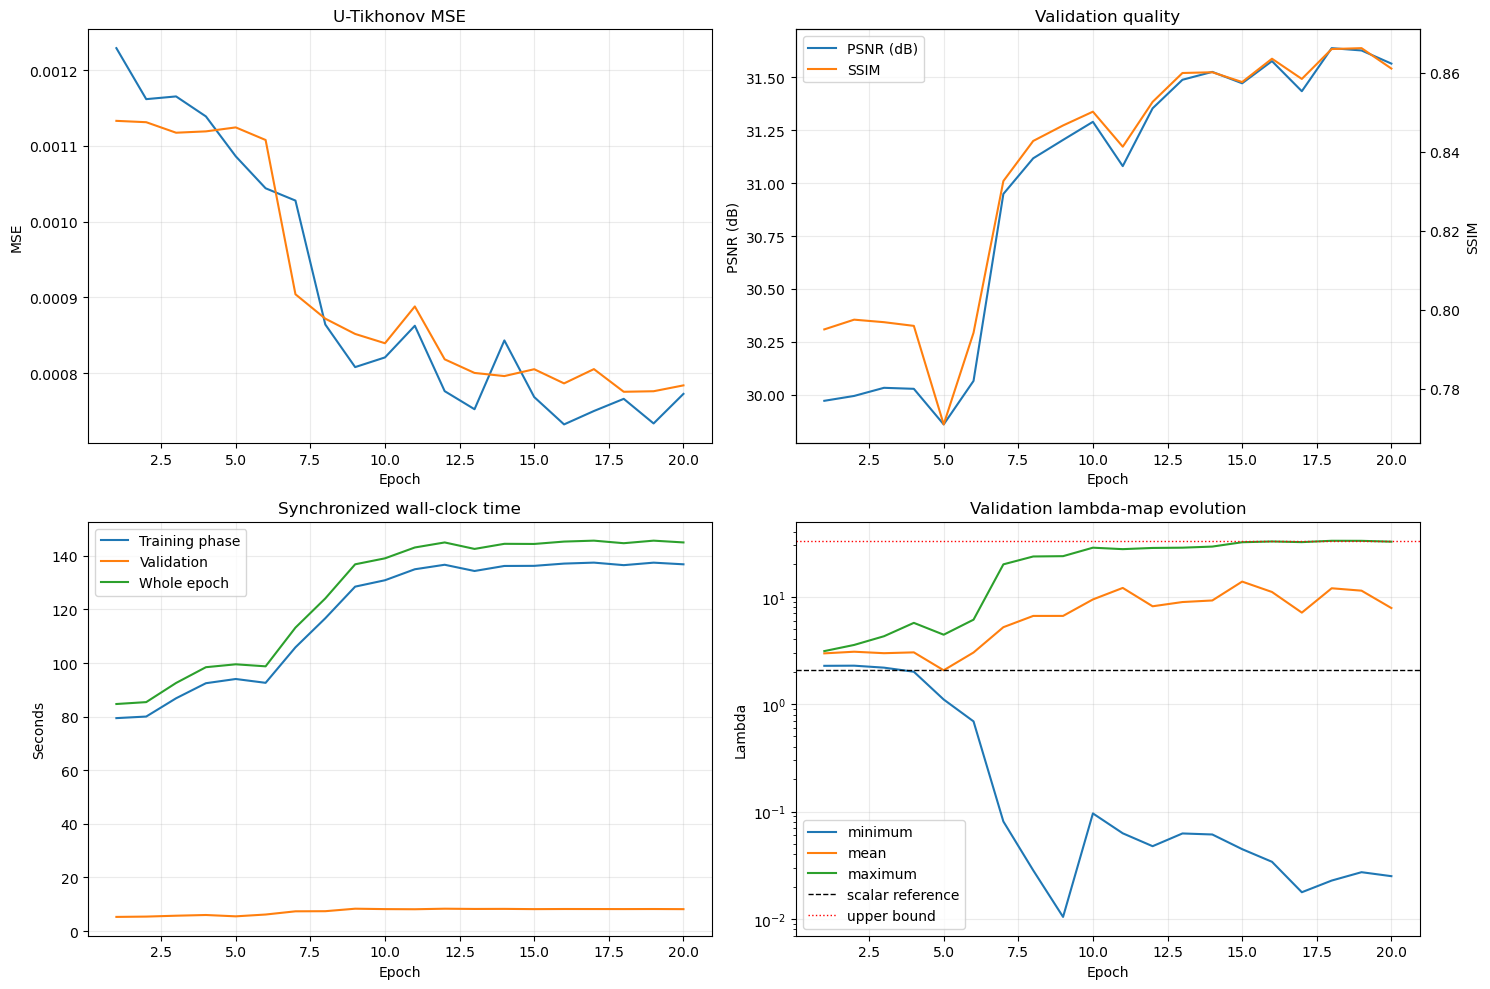

,model_name,device,device_description,torch_version,parameter_count,epochs,training_images,validation_images,best_epoch,best_val_psnr,total_time_sec,mean_epoch_time_sec,mean_train_phase_time_sec,mean_validation_time_sec,mean_train_images_per_sec,solver_iterations
0,u_tikhonov,mps,Apple Metal Performance Shaders (MPS),2.12.0,1925025,20,500,50,18,31.637609,2520.736206,125.947102,118.579449,7.367075,4.389533,64


Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/training/u_tikhonov_bounded_x16_cg64_curves_and_timing.png


In [7]:
history_path = checkpoint_dir / "history.csv"
training_summary_path = checkpoint_dir / "training_summary.csv"
history_high = pd.read_csv(history_path)
training_summary = pd.read_csv(training_summary_path)

figure, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(
    history_high["epoch"],
    history_high["train_mse"],
    label="Train",
)
axes[0, 0].plot(
    history_high["epoch"],
    history_high["val_mse"],
    label="Validation",
)
axes[0, 0].set(
    title="U-Tikhonov MSE",
    xlabel="Epoch",
    ylabel="MSE",
)

axes[0, 1].plot(
    history_high["epoch"],
    history_high["val_psnr"],
    label="PSNR (dB)",
)
psnr_axis = axes[0, 1]
ssim_axis = psnr_axis.twinx()
ssim_axis.plot(
    history_high["epoch"],
    history_high["val_ssim"],
    color="tab:orange",
    label="SSIM",
)
psnr_axis.set(
    title="Validation quality",
    xlabel="Epoch",
    ylabel="PSNR (dB)",
)
ssim_axis.set_ylabel("SSIM")
lines = psnr_axis.lines + ssim_axis.lines
psnr_axis.legend(lines, [line.get_label() for line in lines])

axes[1, 0].plot(
    history_high["epoch"],
    history_high["train_phase_time_sec"],
    label="Training phase",
)
axes[1, 0].plot(
    history_high["epoch"],
    history_high["validation_time_sec"],
    label="Validation",
)
axes[1, 0].plot(
    history_high["epoch"],
    history_high["epoch_time_sec"],
    label="Whole epoch",
)
axes[1, 0].set(
    title="Synchronized wall-clock time",
    xlabel="Epoch",
    ylabel="Seconds",
)
axes[1, 0].legend()

for column, label in (
    ("val_lambda_min", "minimum"),
    ("val_lambda_mean", "mean"),
    ("val_lambda_max", "maximum"),
):
    if column in history_high:
        axes[1, 1].plot(
            history_high["epoch"],
            history_high[column],
            label=label,
        )
axes[1, 1].axhline(
    reference_lambda,
    color="black",
    linestyle="--",
    linewidth=1,
    label="scalar reference",
)
axes[1, 1].axhline(
    lambda_max,
    color="red",
    linestyle=":",
    linewidth=1,
    label="upper bound",
)
axes[1, 1].set(
    title="Validation lambda-map evolution",
    xlabel="Epoch",
    ylabel="Lambda",
)
axes[1, 1].set_yscale("log")
axes[1, 1].legend()

for axis in axes.ravel():
    axis.grid(alpha=0.25)

figure.tight_layout()
figure_path = (
    PROJECT_ROOT
    / "results"
    / "training"
    / f"{RUN_NAME}_curves_and_timing.png"
)
figure_path.parent.mkdir(parents=True, exist_ok=True)
figure.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(figure)

display(training_summary)
print("Saved:", figure_path)

In [8]:
saturation_columns = [
    column
    for column in history_high
    if "saturation_fraction" in column
]
if saturation_columns:
    display(history_high[["epoch", *saturation_columns]].tail())
else:
    print("No bounded-map saturation columns were found.")

,epoch,val_lambda_lower_saturation_fraction,val_lambda_upper_saturation_fraction
15,16,0.006239,0.000000
16,17,0.011111,0.000000
17,18,0.006719,0.003877
18,19,0.006055,0.001895
19,20,0.006495,0.000000


## Post-training CG accuracy audit

For ten fixed validation images, compare the learned 64-step output with CG
solved to a strict residual tolerance using the *same learned lambda map*.
Small reconstruction differences mean solver truncation is not driving the
reported denoising result.

In [9]:
@torch.no_grad()
def audit_fixed_cg(
    model,
    loader,
    *,
    images=10,
    converged_max_iter=256,
    converged_tol=1e-8,
):
    rows = []
    for image_index, batch in enumerate(loader):
        if image_index >= images:
            break

        clean = batch["clean"].to(device)
        noisy = batch["noisy"].to(device)
        fixed, lambda_map = model(noisy)

        def operator(image):
            return weighted_tikhonov_operator(image, lambda_map)

        converged, info = cg_solve_until_converged(
            A=operator,
            b=noisy,
            x0=noisy,
            max_iter=converged_max_iter,
            tol=converged_tol,
            check_spd=True,
        )

        fixed_norm = torch.linalg.vector_norm(fixed).clamp_min(1e-12)
        noisy_norm = torch.linalg.vector_norm(noisy).clamp_min(1e-12)
        fixed_residual = torch.linalg.vector_norm(
            operator(fixed) - noisy
        ) / noisy_norm
        solution_difference = torch.linalg.vector_norm(
            fixed - converged
        ) / fixed_norm

        fixed_scored = fixed.clamp(0.0, 1.0)
        converged_scored = converged.clamp(0.0, 1.0)
        rows.append(
            {
                "image_index": image_index,
                "path": batch["path"][0],
                "fixed_cg_iters": model.cg_iters,
                "converged_cg_iters": info["num_iter"],
                "converged": info["converged"],
                "fixed_relative_residual": float(fixed_residual),
                "relative_solution_difference": float(solution_difference),
                "fixed_psnr": float(batch_psnr(fixed_scored, clean)[0]),
                "converged_psnr": float(
                    batch_psnr(converged_scored, clean)[0]
                ),
                "fixed_ssim": float(batch_ssim(fixed_scored, clean)[0]),
                "converged_ssim": float(
                    batch_ssim(converged_scored, clean)[0]
                ),
                "lambda_min": float(lambda_map.min()),
                "lambda_mean": float(lambda_map.mean()),
                "lambda_max": float(lambda_map.max()),
            }
        )
    return pd.DataFrame(rows)


cg_audit = audit_fixed_cg(model_tikhonov_high, val_loader)
cg_audit_path = checkpoint_dir / "post_training_cg_audit.csv"
cg_audit.to_csv(cg_audit_path, index=False)

display(cg_audit)
display(
    cg_audit[
        [
            "fixed_relative_residual",
            "relative_solution_difference",
            "fixed_psnr",
            "converged_psnr",
            "fixed_ssim",
            "converged_ssim",
        ]
    ].agg(["mean", "max"])
)
print("Saved:", cg_audit_path)

,image_index,path,fixed_cg_iters,converged_cg_iters,converged,fixed_relative_residual,relative_solution_difference,fixed_psnr,converged_psnr,fixed_ssim,converged_ssim,lambda_min,lambda_mean,lambda_max
0,0,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,64,144,False,0.000300,5.779569e-05,30.717152,30.716949,0.890834,0.890833,0.058514,11.936287,31.639702
1,1,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,64,141,False,0.000225,4.202991e-05,26.007179,26.007183,0.742747,0.742744,0.128490,3.450726,31.289551
2,2,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,64,95,False,0.000005,6.157759e-07,28.891628,28.891628,0.851207,0.851212,0.090139,3.132269,16.266207
3,3,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,64,114,False,0.000019,3.787240e-06,32.802040,32.802013,0.852916,0.852913,0.235445,4.859087,25.518938
4,4,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,64,142,False,0.000224,4.134608e-05,29.917307,29.917173,0.844324,0.844317,0.203578,6.704931,31.625154
5,5,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,64,131,False,0.000105,2.067456e-05,28.736420,28.736301,0.846252,0.846255,0.024996,6.268508,28.580448
6,6,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,64,143,False,0.000234,4.318081e-05,30.737799,30.737696,0.835807,0.835817,0.099815,8.163198,32.230503
7,7,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,64,144,False,0.000246,4.491231e-05,30.928766,30.928499,0.881112,0.881112,0.157270,7.770386,32.414040
8,8,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,64,107,False,0.000011,2.173736e-06,30.511923,30.511906,0.860697,0.860660,0.179587,3.638257,21.169880
9,9,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,64,111,False,0.000018,3.620679e-06,30.771523,30.771521,0.859900,0.859903,0.276786,3.342615,23.679995


,fixed_relative_residual,relative_solution_difference,fixed_psnr,converged_psnr,fixed_ssim,converged_ssim
mean,0.000139,0.000026,30.002174,30.002087,0.846580,0.846577
max,0.000300,0.000058,32.802040,32.802013,0.890834,0.890833


Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/checkpoints/u_tikhonov_bounded_x16_cg64/post_training_cg_audit.csv
